### **We clipped based on HydroSHEDS Level 7 watershed data**

In [2]:
import rasterio as rio
from rasterio.merge import merge
from rasterio.windows import Window
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('..')
from utils.imgShow import imsShow
from rasterio.warp import reproject, Resampling

In [3]:
input_dir = '../data/result'                 
output_path = '../data/result/2025_pred_merged.tif'  

file_pattern = os.path.join(input_dir, 'S2_2025_*.tif')
src_files = glob.glob(file_pattern)

src_datasets = [rio.open(fp) for fp in src_files]

mosaic, out_transform = merge(src_datasets, method='max')

out_meta = src_datasets[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform,
})

with rio.open(output_path, "w", **out_meta) as dest:
    dest.write(mosaic)

for src in src_datasets:
    src.close()

print(f"输出文件：{output_path}")

输出文件：../data/result/2025_pred_merged.tif


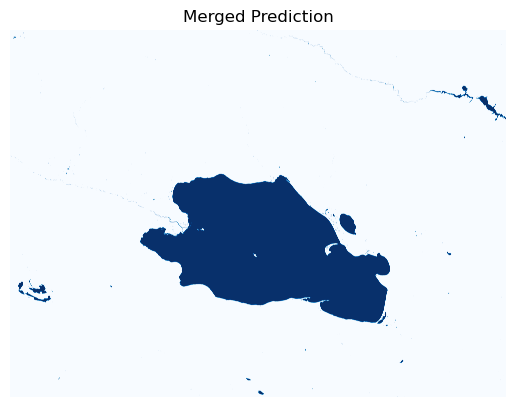

In [4]:
with rio.open(output_path) as src:
    img = src.read(1) 
plt.imshow(img, cmap='Blues')
plt.title("Merged Prediction")
plt.axis('off')
plt.show()

In [5]:
input_raster = '../data/result/2025_pred_merged.tif'  # 待裁剪的栅格
mask_raster  = '../data/truth/qinghai_lake_basin.tif'    # 掩膜栅格（值为1的区域保留）
output_raster = '../data/result/2025_pred_masked.tif'    

def align_mask_to_target(mask_path, target_profile):
    """将掩膜重采样到目标栅格的格网（最近邻插值）"""
    with rio.open(mask_path) as src:
        mask_aligned = np.zeros((target_profile['height'], target_profile['width']), dtype=np.uint8)
        reproject(
            source=rio.band(src, 1),
            destination=mask_aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_profile['transform'],
            dst_crs=target_profile['crs'],
            resampling=Resampling.nearest
        )
        return mask_aligned, src.nodata

with rio.open(input_raster) as src_target:
    target_profile = src_target.profile
    target_data = src_target.read()  

    # 检查掩膜是否对齐
    with rio.open(mask_raster) as src_mask:
        same_crs = src_target.crs == src_mask.crs
        same_shape = src_target.shape == src_mask.shape
        same_transform = np.allclose(src_target.transform, src_mask.transform, atol=1e-9)

        if same_crs and same_shape and same_transform:
            print("掩膜与目标栅格完全对齐，直接使用原始掩膜。")
            mask = src_mask.read(1)
            mask_nodata = src_mask.nodata
        else:
            print("掩膜与目标栅格不对齐，重采样对齐...")
            mask, mask_nodata = align_mask_to_target(mask_raster, target_profile)

    # 构建有效区域掩膜（值为1的区域）
    if mask_nodata is not None:
        valid_mask = (mask == 1) & (mask != mask_nodata)
    else:
        valid_mask = (mask == 1)

    # 创建输出数组（用目标文件的 nodata 填充）
    out_nodata = target_profile.get('nodata', 0)
    if out_nodata is None:
        out_nodata = 0
    out_image = np.full_like(target_data, out_nodata, dtype=target_profile['dtype'])

    # 应用掩膜：只保留 valid_mask 为 True 的像素
    for band in range(target_data.shape[0]):
        out_image[band][valid_mask] = target_data[band][valid_mask]

    out_profile = target_profile.copy()
    out_profile.update({'nodata': out_nodata})
    with rio.open(output_raster, 'w', **out_profile) as dst:
        dst.write(out_image)

print(f"裁剪完成！输出文件：{output_raster}")

掩膜与目标栅格不对齐，重采样对齐...
裁剪完成！输出文件：../data/result/2025_pred_masked.tif


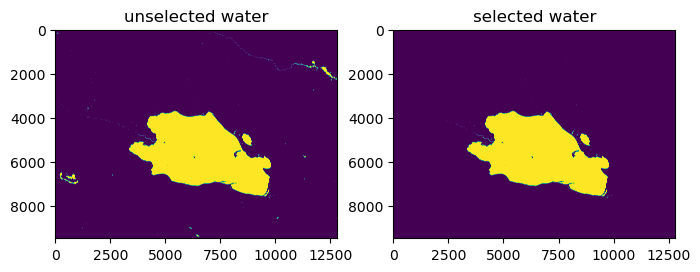

In [6]:

with rio.open(input_raster) as img_src, rio.open(output_raster) as pred_src:
    img_arr = img_src.read(1) 
    pred_arr = pred_src.read(1)  
imsShow([img_arr, pred_arr], ['unselected water', 'selected water'], figsize=(8, 3))